
# 0. Probleemstelling extreme neerslag

Noot: Repliceerbaarheid en versioning:

    Indien deze nota in pdf of word ter beschikking is kan men steeds de nieuwste versie en de repliceerbare code op github vinden.
    https://github.com/ReinhardStoop/neerslag_vs



## context

Op de website van Statistiek Vlaanderen wordt een VOS gepubliceert over de neerslagextremen. 
zie https://www.vlaanderen.be/statistiek-vlaanderen/milieu-en-natuur/neerslagextremen

Deze cijfers en trendanalyse worden aangeleverd door VMM die deze zelf ook publiceerd online
zie https://vmm.vlaanderen.be/feiten-cijfers/klimaat/klimaatthemas/wateroverlast-door-hevige-regenval/indicator-neerslagextremen

Ook de bron KMI publiceerd deze gegevens en analyse:
https://www.meteo.be/nl/klimaat/klimaatverandering-in-belgie/klimaattrends-in-ukkel/neerslag/extremiteitsindices/max-10-dagen-neerslag
Op de website van het KMI vind meen ook een klimaatrapport waarin ook de methdologie wordt uitgelegd van de trend analyses op de klimaattijdreeksen. 
zie https://www.meteo.be/nl/klimaat/klimaatverandering-in-belgie/klimaatrapporten
Dit klimaatrapport dateerd van 2020 maar geeft wel helder weer wat de methdologie en de methdologische overwegingen zijn geweest met betrekking tot het anlyseren van de tijdsreeksen.

We gebruiken in deze kwaliteits evaluatie ook zeer expliciet volgend referentie werk (KNMI) dat ook door het KMI voor haar klimaatrapportering wordt gebruikt.

KNMI:
**Standard method for determining a climatological trend** 
C.F. de Valk De Bilt, 2020 | Technical report; TR-389
https://cdn.knmi.nl/system/ckeditor_assets/attachments/161/TR389.pdf



## Vaststelling

Heel algemeen wijken de trendberekeningen en voorstellingen van VMM soms af van deze van het KMI. 

In het bezonder bekijken we in deze nota de reeks van neerslagextremen van 10 dagen. 
    Door de VMM (en door VSA overgenomen) wordt op de ganse tijdreeks een regressie analyse toegepast. De conclusie is dat er een positieve significante trend is. 
    Op de website van het KMI wordt deze reeks op basis van een LOESS (uitleg zie verder) visueel voorgesteld en geld een trendberekening voor de laatste 30 jaaar die niet significant is.

## Doelstelling 
We doen replicatie en evaluatie van deze berekeningen. Deze wordt uitgevoerd op basis van Python op een repliceerbare manier (https://github.com/ReinhardStoop/neerslag_vs) zodat deze via een notebook future-proof op te nemen is in de VSA Databrick (to-be) omgeving.

## Aanpak

    -We werken met de data de methodiek uit van het KMI; We doen dus met de meest recente data een replicationderzoek volgens de KMI methodiek (zie Klimaatrapport)

    -We doen een replicatie van de Regressie analyse van de VMM. We leggen daarbij de statistische beperkingen en erva uit en doen test's met betrekking tot het schenden van Gaus-Markov voorwaarden voor het toepassen van een enkelvoudige OLS regressie. We bespreken deze methdoiek ook inhoudelijk binnen de context van klimaatonderzoek en de voorwaarden en beperkingen daarvan. 

    -Ten slotte doen we een round up van de KMI methodiek en zetten we een kleine stap verder in het tijdreeksonderzoek. Zonderdaarbij een claim te leggen dat dit een klimaatwetenschappelijk onderzoek zou zijn. 
















# Extreme neerslag in Belgie: jaarlijkse maxima over 10 dagen

Deze notebook analyseert de jaarlijkse maximale neerslag over een periode van 10 opeenvolgende dagen. De focus ligt op drie vragen:

1. Hoe evolueert de volledige meetreeks doorheen de tijd? Klopt het dat men een regressie OLS kan gebruiken over de ganse periode zoals VEKA dit doet. zie https://vmm.vlaanderen.be/feiten-cijfers/klimaat/klimaatthemas/wateroverlast-door-hevige-regenval/
2. Wat indien we de methodiek toepassen zoals deze in het klimaatrapport van het KMI is uitgewerkt en door het KMI gebruikt wordt. 
   Bijkomend: Is er sinds 1981 een recente lineaire trend, zoals in de KMI-klimaatrapportage vaak wordt gebruikt?
3. Ligt het niveau vanaf een recent venster (conform richtlijnen) duidelijk anders dan in de periode ervoor?

De analyse gebruikt de KMI/KNMI-Methodiek als leidraad: een gladde LOESS-curve voor de volledige reeks en een aparte recente trend vanaf 1981. Omdat extreme neerslag veel natuurlijke variabiliteit bevat, rapporteren we naast de schattingen ook robuuste onzekerheid en gevoeligheidschecks.


## 1. Setup en data

De ruwe Excel wordt (toegeleverd door VMM), omgezet naar een compacte CSV. Daarna werkt de rest van de notebook uitsluitend met `processed_max_neerslag.csv`, zodat de analyse reproduceerbaar en sneller uitvoerbaar blijft.

**API ?**
*De neerslag extremenjaarlijkse punt-data zoals in de VOS zijn opgenomen en op de website van VMM en KMI te vinden zijn, zitten niet alsdusdanig in de KMI open data API. 
De KMI Open Data API bevat wel de ruwe neerslagwaarnemingen waarmee extreme-neerslagindicatoren berekend kunnen worden, maar er is geen kant-en-klare open-data API-laag voor “extreme neerslag” als afgeleide klimaatindicator. Indien we de exacte berekeningen kennen is het in principe mogelijk de data-'ingress' te automatiseren. Mogelijk no te ontwikkelen. *



In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')

PROJECT_ROOT_CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
DATA_DIR = next((p / 'data' for p in PROJECT_ROOT_CANDIDATES if (p / 'data').exists()), Path('../data'))
CSV_PATH = DATA_DIR / 'processed_max_neerslag.csv'
EXCEL_CANDIDATES = [
    Path('../../Maximale neerslag.xlsx'),
    Path('../Maximale neerslag.xlsx'),
    Path('Maximale neerslag.xlsx'),
]

OBS_COL = 'Waarneming 10 dagen'
TREND_COL = 'Trendlijn 10 dagen'
START_RECENT = 1981
LOESS_FRAC = 0.25

plt.rcParams.update({
    'figure.figsize': (11, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.22,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.frameon': False,
})

COLORS = {
    'observed': '#4B5563',
    'loess': '#2563EB',
    'recent': '#DC2626',
    'accent': '#059669',
    'neutral': '#9CA3AF',
}


def create_processed_csv_from_excel(output_path=CSV_PATH):
    excel_path = next((path for path in EXCEL_CANDIDATES if path.exists()), None)
    if excel_path is None:
        raise FileNotFoundError(
            'Geen processed CSV en geen Excel-bestand gevonden. '
            'Plaats Maximale neerslag.xlsx in de projectmap of voer de datavoorbereiding uit.'
        )

    raw = pd.read_excel(excel_path, sheet_name='Data', engine='openpyxl')
    years = raw.iloc[2, 1:].values
    processed = pd.DataFrame({
        'Waarneming 1 uur': raw.iloc[9, 1:].values,
        'Waarneming 1 dag': raw.iloc[10, 1:].values,
        'Waarneming 10 dagen': raw.iloc[11, 1:].values,
        'Trendlijn 1 uur': raw.iloc[12, 1:].values,
        'Trendlijn 1 dag': raw.iloc[13, 1:].values,
        'Trendlijn 10 dagen': raw.iloc[14, 1:].values,
    }, index=years)
    processed.index.name = 'Jaar'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    processed.to_csv(output_path)
    return output_path


def load_extreme_series(csv_path=CSV_PATH):
    if not csv_path.exists():
        create_processed_csv_from_excel(csv_path)

    df = pd.read_csv(csv_path)
    extreme = (
        df[['Jaar', OBS_COL]]
        .dropna()
        .rename(columns={OBS_COL: 'max10d_mm'})
        .assign(Jaar=lambda x: x['Jaar'].astype(int))
        .sort_values('Jaar')
        .reset_index(drop=True)
    )
    return df, extreme


def hac_lags(n):
    return max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))


def format_p(value):
    if pd.isna(value):
        return ''
    return '<0,001' if value < 0.001 else f'{value:.3f}'.replace('.', ',')


df, extreme = load_extreme_series()
extreme.head()


,Jaar,max10d_mm
0,1898,67.49
1,1899,84.30
2,1900,79.73
3,1901,60.70
4,1902,57.80


## 2. Beschrijving van de reeks

We selecteren voor de verdere analyse enkel de 10 dagen reeks. Elk punt is dus het hoogste 10-daagse neerslagtotaal binnen een jaar, niet het gemiddelde van dagen. Daardoor is de variabiliteit groot en moeten trends voorzichtig worden geinterpreteerd.


,Kenmerk,Waarde
0,Aantal jaren,127
1,Periode,1898-2024
2,Gemiddelde,86.1 mm
3,Mediaan,84.6 mm
4,Standaardafwijking,19.8 mm
5,Maximum,158.8 mm
6,Jaar van maximum,1996


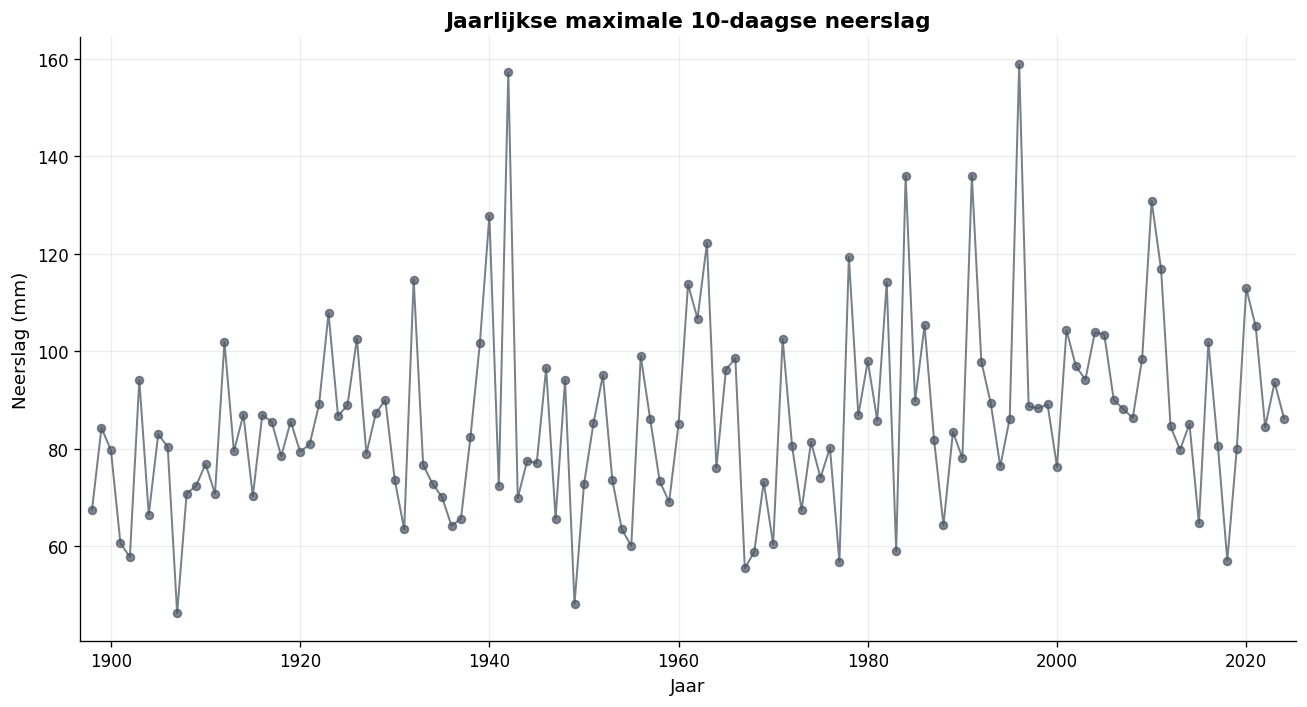

In [2]:
years = extreme['Jaar'].to_numpy(dtype=float)
values = extreme['max10d_mm'].to_numpy(dtype=float)

summary = pd.DataFrame({
    'Kenmerk': [
        'Aantal jaren',
        'Periode',
        'Gemiddelde',
        'Mediaan',
        'Standaardafwijking',
        'Maximum',
        'Jaar van maximum',
    ],
    'Waarde': [
        len(extreme),
        f'{int(years.min())}-{int(years.max())}',
        f'{values.mean():.1f} mm',
        f'{np.median(values):.1f} mm',
        f'{values.std(ddof=1):.1f} mm',
        f'{values.max():.1f} mm',
        int(years[values.argmax()]),
    ],
})

display(summary)

fig, ax = plt.subplots()
ax.plot(extreme['Jaar'], extreme['max10d_mm'], color=COLORS['observed'], linewidth=1.2, alpha=0.75)
ax.scatter(extreme['Jaar'], extreme['max10d_mm'], color=COLORS['observed'], s=22, alpha=0.70)
ax.set_title('Jaarlijkse maximale 10-daagse neerslag')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


#3. KMI methode 
##3.1. Methdologische samenvatting klimaatrapport KMI

In het KMI klimaatrapport kan men qua methdologie als volgt samenvatten indien we deze plaatsen in de context van onze probleemstelling.

In dit KMI-klimaatrapport wordt voor de waargenomen tijdreeksen eigenlijk een vrij duidelijke tweesporenmethode gebruikt:

**1. Lange, gehomogeniseerde tijdreeksen**

Vooraleer trends worden berekend, benadrukt het KMI dat je alleen zinvol klimaatverandering kunt analyseren met kwaliteitsvolle, voldoende lange en zo homogeen mogelijke tijdreeksen. Ze corrigeren dus eerst voor niet-klimatologische breuken zoals verhuis van meetstation, wijziging van instrumenten, meetomgeving, waarnemingsprocedures, enz. Dat noemen ze homogenisatie. Zonder die stap kan je een kunstmatige trend meten die eigenlijk door meetomstandigheden komt, niet door klimaatverandering. In dit geval komt de meting uit één weerstation.

**2. Voor de grafieken systematisch twee technieken**

Het meest expliciet staat dit in het kader “Bepaling van klimatologische trends in de waarnemingen” rond pagina 7 van het rapport. Daar staat dat ze in de grafieken systematisch twee technieken toepassen:

A. LOESS / lokale regressie als gladde trendcurve

Voor de volledige lange periode gebruiken ze een spline-kromme op de jaarlijkse waarden. Die neemt de interjaarlijkse variabiliteit weg en geeft een kwalitatief beeld van de meestal niet-lineaire trend over de hele periode. Het rapport zegt expliciet dat deze curve wordt geschat met een lokale regressiemethode: LOESS.

Dit is dus de aanbevolen methode om de vorm van de klimaatevolutie te bekijken: niet forceren dat de trend over 1833–2019 één rechte lijn is, maar toelaten dat er periodes zijn met stabiliteit, versnelling, afvlakking, enz.

Voor temperatuur zie je dat ook inhoudelijk: de gemiddelde temperatuur bleef relatief stabiel in twee grote periodes, ongeveer 1833–1910 en 1911–1985, waarna vanaf 1986 duidelijk hogere waarden optreden. Een globale lineaire trend over heel 1833–2019 zou die structuur verdoezelen.

B. Lineaire regressie vanaf 1981 (ie laatste 30 jaar) om de recente trend te kwantificeren

Daarnaast passen ze een regressielijn op de jaarlijkse waarden sinds 1981 toe. Die dient om de recente lineaire trend te kwantificeren, bijvoorbeeld in °C per decennium, mm per decennium, dagen per decennium of % per decennium. De helling wordt alleen in de legende vermeld wanneer ze statistisch significant is.

Bijvoorbeeld voor de jaargemiddelde temperatuur in Brussel-Ukkel rapporteren ze sinds 1981 een significante opwarming van +0,38°C per decennium. Voor de seizoenen rapporteren ze eveneens significante trends: winter +0,45°C, lente +0,39°C, zomer +0,40°C en herfst +0,31°C per decennium.

**3. Wat bedoelen ze met “significant”**?

In dit rapport is “significant” niet altijd exact hetzelfde criterium. Voor de Ukkel-grafieken zeggen ze dat een trend significant is wanneer de geschatte helling met minstens 90% waarschijnlijkheid aan een werkelijke trend in de waarnemingen kan worden toegeschreven.

Voor de ruimtelijke analyse over België, bijvoorbeeld temperatuurtrends 1954–2019, spreken ze over trends die statistisch verschillend zijn van nul op het 95%-significantieniveau. De kaarten tonen stations met een zwarte stip wanneer de trend significant is.

Dus: voor Ukkel gebruikt het rapport vaak een 90%-criterium; voor de ruimtelijke kaarten eerder 95%.

**4. Welke methode is dus “aanbevolen” om te bepalen of het klimaat wijzigt?**

Kort gezegd:

Voor detectie en beschrijving van klimaatverandering over lange tijd:

gebruik gehomogeniseerde lange tijdreeksen + LOESS/lokale regressie om de niet-lineaire evolutie zichtbaar te maken.

Voor kwantificering van recente klimaatverandering:

gebruik lineaire regressie vanaf een recente referentieperiode, hier meestal sinds 1981, en rapporteer de helling per decennium met significantietoets.



**5. Belangrijke nuance: gewoon “OLS over de volledige eeuw” is expliciet en impliciet in dit rapport uitgesloten**

Het KMI gebruikt geen eenvoudige globale lineaire regressie over de volledige beschikbare periode als hoofdboodschap voor klimaatverandering. Voor de lange periode gebruiken ze LOESS om de niet-lineaire trend te tonen. De lineaire regressie wordt beperkt tot de recente periode sinds 1981 om de huidige trend te kwantificeren.

Omdat klimaatreeksen vaak niet-stationair zijn en omdat de trend niet constant is over 150 à 200 jaar. Eén rechte lijn over 1833–2019 zou methodologisch te grof zijn.

**6. Inhoudelijke resultaten uit het rapport: Voor temperatuur is het resultaat zeer duidelijk; voor neerslag veel minder**

Voor temperatuur concludeert het KMI ondubbelzinnig dat de seizoens- en jaartemperaturen sinds de 19e eeuw gestegen zijn, met een sterkere tweede opwarming vanaf het einde van de jaren 1980.

Voor neerslag zijn de resultaten minder eenduidig. Het rapport stelt dat neerslag in Ukkel veel minder uitgesproken trends vertoont dan temperatuur, deels door de grote natuurlijke variabiliteit. Jaarlijkse en winterse neerslag vertonen op lange termijn een toenemende trend, maar sinds 1981 is de jaarlijkse neerslagtrend niet significant. Voor sommige extremen, zoals aantal dagen met zware neerslag of maximale uurneerslag, worden wel significante toenames gevonden.

**7. Samenvatting**

Het KMI beveelt impliciet een combinatie aan van homogenisatie, niet-lineaire trendvisualisatie met LOESS en kwantificering van recente trends met lineaire regressie sinds 1981. LOESS dient om de klimaatevolutie over de volledige periode te beschrijven zonder een constante trend te veronderstellen. De lineaire regressie sinds 1981 dient om de recente verandering in interpreteerbare eenheden per decennium te rapporteren en op significantie te toetsen.

Een simpele OLS-trend over de volledige lange tijdreeks is volgens deze aanpak te simplistisch voor klimaatcommunicatie, omdat die de fasering en versnelling van klimaatverandering kan maskeren. Voor temperatuur is de recente lineaire trend sinds 1981 zeer bruikbaar; zeker voor neerslag moet je veel voorzichtiger zijn wegens grotere variabiliteit en minder consistente significantie.




## 3.2 Volledige tijdreeks: LOESS als beschrijvende trend tem 2025

Voor de volledige periode gebruiken we LOESS. Zoals ook in het klimaatrapport en methodiek van KMI en KNMI voorgeschreven wordt. Die curve vat de vorm van de evolutie samen zonder een rechte lijn op te leggen aan de volledige meetperiode. let wel: Dit is een beschrijvende visualisatie en geen significantietest.

LOESS staat voor *Locally Estimated Scatterplot Smoothing*. De methode schat geen enkele globale regressielijn voor de hele tijdreeks, maar past telkens een kleine regressie toe rond elk jaar. Waarnemingen die dichter bij dat jaar liggen krijgen meer gewicht dan waarnemingen verder weg. Door die lokale schattingen naast elkaar te leggen ontstaat een gladde curve die de onderliggende evolutie volgt, terwijl toevallige jaar-tot-jaar schommelingen minder dominant worden.

De belangrijkste keuze bij LOESS is de gladheidsparameter, hier `frac = 0.25`. Die bepaalt welk deel van de meetreeks telkens wordt gebruikt voor een lokale regressie. Een kleinere waarde volgt de data sterker en kan meer korte schommelingen tonen; een grotere waarde maakt de curve gladder en benadrukt vooral de langetermijnbeweging. LOESS is dus gevoelig voor die instelling en moet vooral als verkennende, beschrijvende methode worden gelezen.

In een klimaatanalyse is de doelstelling om de vorm van de langetermijnevolutie zichtbaar te maken zonder vooraf te veronderstellen dat klimaatverandering over de volledige periode lineair verloopt. Dat is belangrijk bij neerslagextremen, omdat jaarlijkse maxima sterk variabel zijn en omdat periodes van stijging, daling of stabilisatie elkaar kunnen afwisselen. De LOESS-curve helpt dus om patronen, faseringen en mogelijke omslagpunten te tonen. Voor uitspraken over significantie, trendsterkte of recente verandering blijft daarnaast een aparte statistische toets nodig, zoals de lineaire trendanalyse vanaf 1981 in de volgende secties.


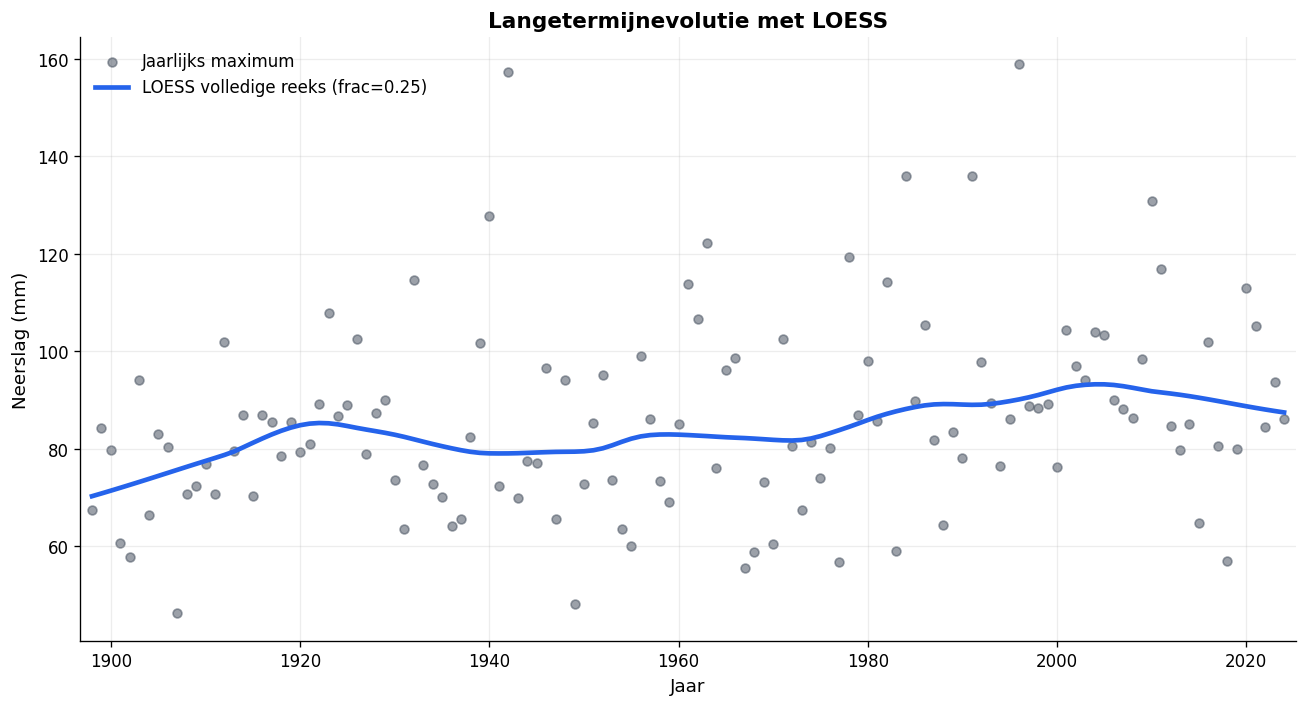

In [3]:
loess_curve = lowess(values, years, frac=LOESS_FRAC, it=1, return_sorted=True)

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.55, s=28, label='Jaarlijks maximum')
ax.plot(
    loess_curve[:, 0],
    loess_curve[:, 1],
    color=COLORS['loess'],
    linewidth=2.8,
    label=f'LOESS volledige reeks (frac={LOESS_FRAC})',
)
ax.set_title('Langetermijnevolutie met LOESS')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left')
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


## 3.3. Recente trend vanaf 1981

De recente verandering wordt apart geschat met een lineaire trend vanaf 1981. De helling wordt uitgedrukt in mm per decennium. De onzekerheid gebruikt HAC/Newey-West standaardfouten, zodat de p-waarde minder gevoelig is voor autocorrelatie en heteroskedasticiteit in de residualen.


,Methode,Schatting,Onzekerheid / toets
0,Lineaire trend met HAC-onzekerheid,-1.47 mm/decennium,"90% BI -4.57 tot 1.62; p = 0,428"
1,Theil-Sen robuuste helling,-0.65 mm/decennium,90% BI -3.80 tot 2.61 mm/decennium
2,Mann-Kendall monotone trend,tau = -0.041,"p = 0,701"


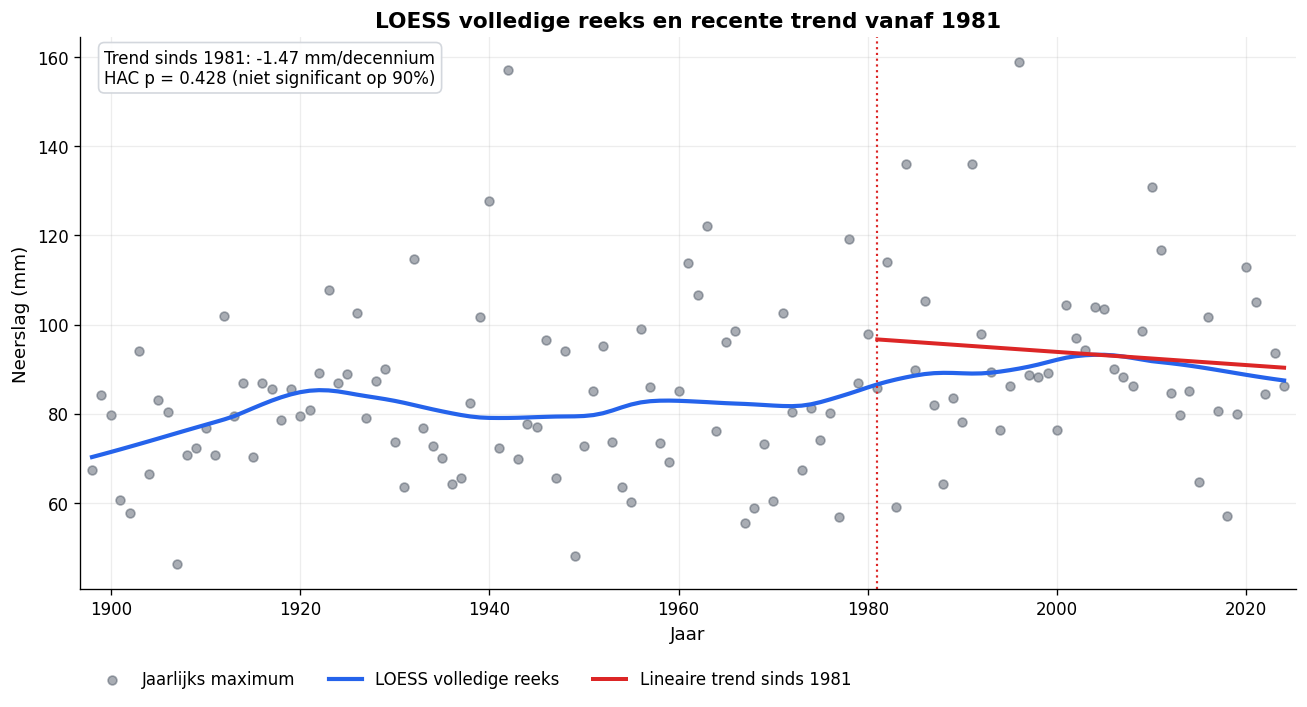

In [ ]:
#bij 3.2. 
recent = extreme.loc[extreme['Jaar'] >= START_RECENT].copy()
t_recent = recent['Jaar'].to_numpy(dtype=float) - START_RECENT
y_recent = recent['max10d_mm'].to_numpy(dtype=float)

ols_recent = sm.OLS(y_recent, sm.add_constant(t_recent)).fit()
recent_hac_lags = hac_lags(len(recent))
hac_recent = ols_recent.get_robustcov_results(cov_type='HAC', maxlags=recent_hac_lags)

slope_year = hac_recent.params[1]
slope_decade = slope_year * 10
ci90 = hac_recent.conf_int(alpha=0.10)[1] * 10
ci95 = hac_recent.conf_int(alpha=0.05)[1] * 10
p_hac = hac_recent.pvalues[1]

sen = stats.theilslopes(y_recent, recent['Jaar'].to_numpy(dtype=float), alpha=0.90)


def mann_kendall_test(series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    s = 0.0
    for k in range(n - 1):
        s += np.sign(series[k + 1:] - series[k]).sum()

    _, counts = np.unique(series, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    var_s = (n * (n - 1) * (2 * n + 5) - tie_term) / 18
    z = (s - 1) / np.sqrt(var_s) if s > 0 else (s + 1) / np.sqrt(var_s) if s < 0 else 0.0
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    tau = s / (0.5 * n * (n - 1))
    return tau, p_value


mk_tau, mk_p = mann_kendall_test(y_recent)
trend_table = pd.DataFrame({
    'Methode': [
        'Lineaire trend met HAC-onzekerheid',
        'Theil-Sen robuuste helling',
        'Mann-Kendall monotone trend',
    ],
    'Schatting': [
        f'{slope_decade:.2f} mm/decennium',
        f'{sen.slope * 10:.2f} mm/decennium',
        f'tau = {mk_tau:.3f}',
    ],
    'Onzekerheid / toets': [
        f'90% BI {ci90[0]:.2f} tot {ci90[1]:.2f}; p = {format_p(p_hac)}',
        f'90% BI {sen.low_slope * 10:.2f} tot {sen.high_slope * 10:.2f} mm/decennium',
        f'p = {format_p(mk_p)}',
    ],
})

display(trend_table)

recent_fit = hac_recent.params[0] + hac_recent.params[1] * t_recent
significance = 'significant op 95%' if p_hac < 0.05 else 'significant op 90%' if p_hac < 0.10 else 'niet significant op 90%'

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.48, s=28, label='Jaarlijks maximum')
ax.plot(loess_curve[:, 0], loess_curve[:, 1], color=COLORS['loess'], linewidth=2.5, label='LOESS volledige reeks')
ax.plot(recent['Jaar'], recent_fit, color=COLORS['recent'], linewidth=2.4, label=f'Lineaire trend sinds {START_RECENT}')
ax.axvline(START_RECENT, color=COLORS['recent'], linestyle=':', linewidth=1.3)
ax.text(
    0.02,
    0.98,
    f'Trend sinds {START_RECENT}: {slope_decade:.2f} mm/decennium\nHAC p = {p_hac:.3f} ({significance})',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('LOESS volledige reeks en recente trend vanaf 1981')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


## 4. OLS regressie volledige reeks

Als eenvoudige referentie schatten we voor de hele meetperiode een gewone OLS-regressie met een lineaire tijdtrend. Deze rechte lijn is vooral een samenvattende toets: ze laat zien of er gemiddeld over de volledige reeks een lineaire stijging of daling aanwezig is, terwijl de LOESS-curve daarnaast de niet-lineaire vorm van de evolutie blijft tonen.


,Parameter,Schatting,Std. fout,t-waarde,p-waarde,CI95 laag,CI95 hoog,Eenheid
0,Intercept,77.297,3.386,22.826,"<0,001",70.595,83.999,mm bij startjaar
1,Trend,1.399,0.465,3.011,"0,003",0.479,2.318,mm/decennium


,Kenmerk,Waarde
0,Aantal jaren,127
1,Periode,1898-2024
2,R-kwadraat,0.067606
3,Adjusted R-kwadraat,0.060146
4,F-statistic p-waarde,"0,003"
5,RMSE residualen (mm),19.04232


,Test,Waarde
0,Durbin-Watson residualen,2.002129
1,Lag-1 autocorrelatie residualen,-0.002953
2,Ljung-Box lag 10 p-waarde,"0,544"
3,Breusch-Pagan p-waarde,"0,390"
4,Shapiro-Wilk p-waarde,"<0,001"


,Ljung-Box statistic,p-waarde
1,0.0011,0.9733
5,2.0525,0.8418
10,8.8798,0.5435


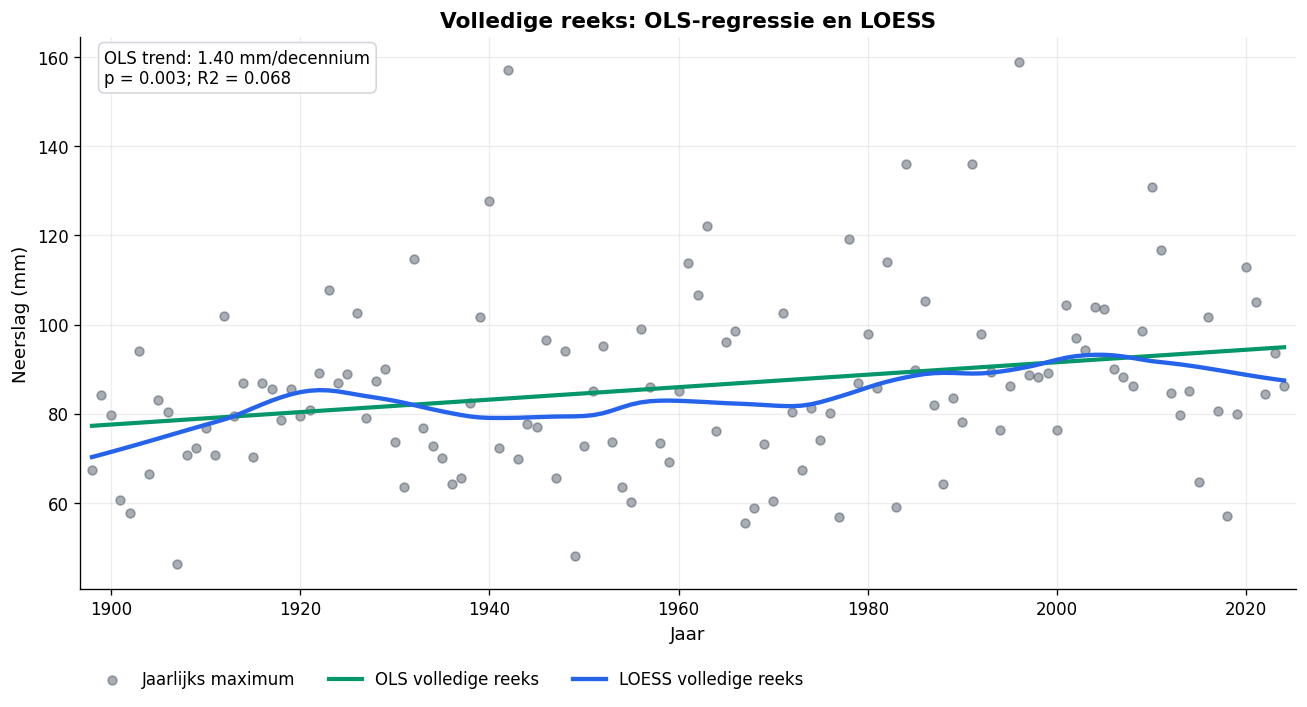

In [4]:
# Gewone OLS-regressie over de volledige reeks
t_full = years - years.min()
ols_full = sm.OLS(values, sm.add_constant(t_full)).fit()
full_fit = ols_full.predict(sm.add_constant(t_full))
full_residuals = pd.Series(ols_full.resid, index=extreme['Jaar'])

slope_full_year = ols_full.params[1]
slope_full_decade = slope_full_year * 10
ci95_full_decade = ols_full.conf_int(alpha=0.05)[1] * 10
p_full = ols_full.pvalues[1]

ols_table = pd.DataFrame({
    'Parameter': ['Intercept', 'Trend'],
    'Schatting': [ols_full.params[0], slope_full_decade],
    'Std. fout': [ols_full.bse[0], ols_full.bse[1] * 10],
    't-waarde': [ols_full.tvalues[0], ols_full.tvalues[1]],
    'p-waarde': [format_p(ols_full.pvalues[0]), format_p(p_full)],
    'CI95 laag': [ols_full.conf_int(alpha=0.05)[0, 0], ci95_full_decade[0]],
    'CI95 hoog': [ols_full.conf_int(alpha=0.05)[0, 1], ci95_full_decade[1]],
    'Eenheid': ['mm bij startjaar', 'mm/decennium'],
})

model_fit_table = pd.DataFrame({
    'Kenmerk': [
        'Aantal jaren',
        'Periode',
        'R-kwadraat',
        'Adjusted R-kwadraat',
        'F-statistic p-waarde',
        'RMSE residualen (mm)',
    ],
    'Waarde': [
        int(ols_full.nobs),
        f'{int(years.min())}-{int(years.max())}',
        ols_full.rsquared,
        ols_full.rsquared_adj,
        format_p(ols_full.f_pvalue),
        np.sqrt(np.mean(full_residuals ** 2)),
    ],
})

shapiro_stat, shapiro_p = stats.shapiro(full_residuals)
bp_stat, bp_p, _, _ = sm.stats.diagnostic.het_breuschpagan(full_residuals, ols_full.model.exog)
full_ljung_box = acorr_ljungbox(full_residuals, lags=[1, 5, 10], return_df=True)

diagnostics_full = pd.DataFrame({
    'Test': [
        'Durbin-Watson residualen',
        'Lag-1 autocorrelatie residualen',
        'Ljung-Box lag 10 p-waarde',
        'Breusch-Pagan p-waarde',
        'Shapiro-Wilk p-waarde',
    ],
    'Waarde': [
        durbin_watson(full_residuals),
        full_residuals.autocorr(lag=1),
        format_p(full_ljung_box.loc[10, 'lb_pvalue']),
        format_p(bp_p),
        format_p(shapiro_p),
    ],
})

display(ols_table.round({'Schatting': 3, 'Std. fout': 3, 't-waarde': 3, 'CI95 laag': 3, 'CI95 hoog': 3}))
display(model_fit_table)
display(diagnostics_full)
display(
    full_ljung_box
    .rename(columns={'lb_stat': 'Ljung-Box statistic', 'lb_pvalue': 'p-waarde'})
    .round(4)
)

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.48, s=28, label='Jaarlijks maximum')
ax.plot(years, full_fit, color=COLORS['accent'], linewidth=2.5, label='OLS volledige reeks')
ax.plot(loess_curve[:, 0], loess_curve[:, 1], color=COLORS['loess'], linewidth=2.6, label='LOESS volledige reeks')
ax.text(
    0.02,
    0.98,
    f'OLS trend: {slope_full_decade:.2f} mm/decennium\np = {p_full:.3f}; R2 = {ols_full.rsquared:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('Volledige reeks: OLS-regressie en LOESS')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


,Model,Intercept,Trend (mm/decennium),Std. fout trend,p-waarde trend,CI95 trend laag,CI95 trend hoog,AR(1) rho,R-kwadraat
0,OLS volledige reeks,77.297,1.399,0.465,"0,003",0.479,2.318,NaN,0.0676
1,Regressie met AR(1)-fouten,77.610,1.362,0.470,"0,004",0.431,2.292,-0.0029,0.0633


,Model,Test,Waarde
0,OLS volledige reeks,F-test p-waarde,"0,003"
1,OLS volledige reeks,Durbin-Watson,2.002129
2,OLS volledige reeks,Ljung-Box lag 10 p-waarde,"0,544"
3,Regressie met AR(1)-fouten,Geschatte AR(1) rho,-0.002911
4,Regressie met AR(1)-fouten,Durbin-Watson,2.001992
5,Regressie met AR(1)-fouten,Ljung-Box lag 10 p-waarde,"0,545"


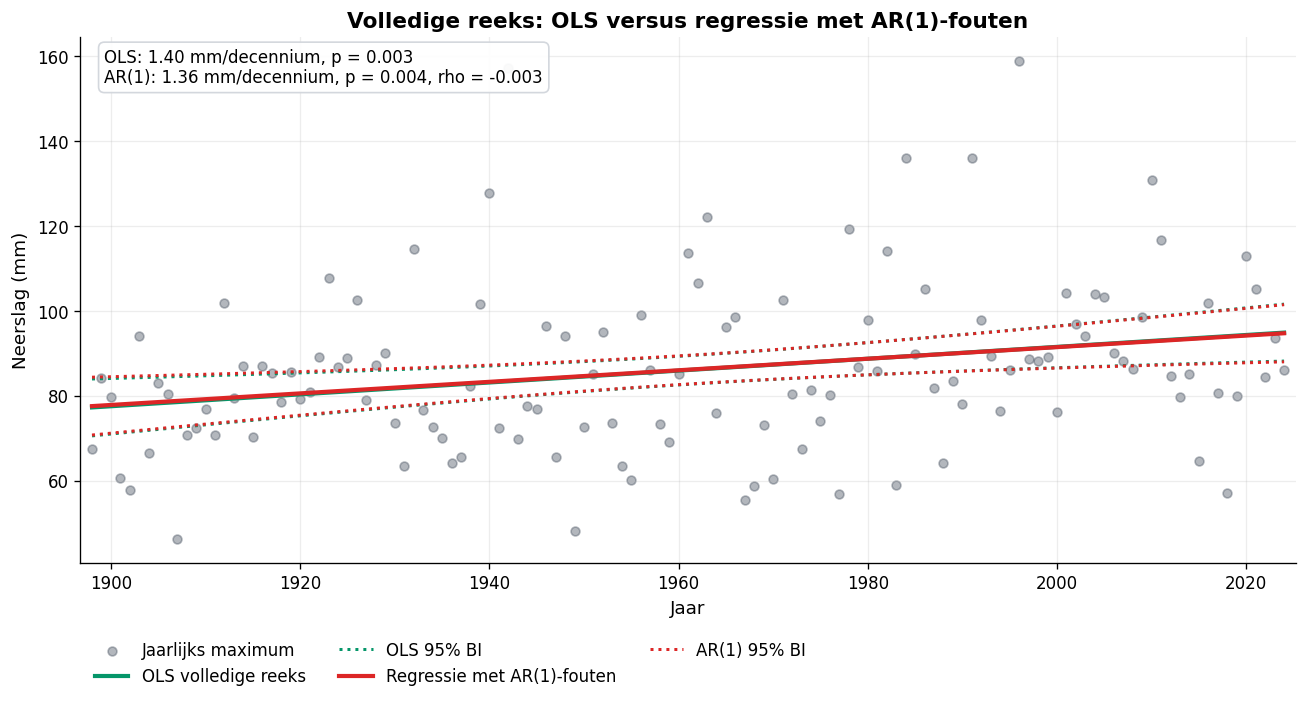

In [5]:
# Vergelijking: gewone OLS versus lineaire regressie met AR(1)-fouten
X_full = sm.add_constant(t_full)

ols_full_compare = sm.OLS(values, X_full).fit()
glsar_full = sm.GLSAR(values, X_full, rho=1)
ar1_full = glsar_full.iterative_fit(maxiter=20)
rho_ar1 = float(np.squeeze(glsar_full.rho))

ols_pred = ols_full_compare.get_prediction(X_full).summary_frame(alpha=0.05)
ar1_pred = ar1_full.get_prediction(X_full).summary_frame(alpha=0.05)

comparison_table = pd.DataFrame({
    'Model': ['OLS volledige reeks', 'Regressie met AR(1)-fouten'],
    'Intercept': [ols_full_compare.params[0], ar1_full.params[0]],
    'Trend (mm/decennium)': [ols_full_compare.params[1] * 10, ar1_full.params[1] * 10],
    'Std. fout trend': [ols_full_compare.bse[1] * 10, ar1_full.bse[1] * 10],
    'p-waarde trend': [format_p(ols_full_compare.pvalues[1]), format_p(ar1_full.pvalues[1])],
    'CI95 trend laag': [ols_full_compare.conf_int(alpha=0.05)[1, 0] * 10, ar1_full.conf_int(alpha=0.05)[1, 0] * 10],
    'CI95 trend hoog': [ols_full_compare.conf_int(alpha=0.05)[1, 1] * 10, ar1_full.conf_int(alpha=0.05)[1, 1] * 10],
    'AR(1) rho': [np.nan, rho_ar1],
    'R-kwadraat': [ols_full_compare.rsquared, ar1_full.rsquared],
})

ols_tests = pd.DataFrame({
    'Model': 'OLS volledige reeks',
    'Test': ['F-test p-waarde', 'Durbin-Watson', 'Ljung-Box lag 10 p-waarde'],
    'Waarde': [
        format_p(ols_full_compare.f_pvalue),
        durbin_watson(ols_full_compare.resid),
        format_p(acorr_ljungbox(ols_full_compare.resid, lags=[10], return_df=True).loc[10, 'lb_pvalue']),
    ],
})

ar1_tests = pd.DataFrame({
    'Model': 'Regressie met AR(1)-fouten',
    'Test': ['Geschatte AR(1) rho', 'Durbin-Watson', 'Ljung-Box lag 10 p-waarde'],
    'Waarde': [
        rho_ar1,
        durbin_watson(ar1_full.resid),
        format_p(acorr_ljungbox(ar1_full.resid, lags=[10], return_df=True).loc[10, 'lb_pvalue']),
    ],
})

display(comparison_table.round({
    'Intercept': 3,
    'Trend (mm/decennium)': 3,
    'Std. fout trend': 3,
    'CI95 trend laag': 3,
    'CI95 trend hoog': 3,
    'AR(1) rho': 4,
    'R-kwadraat': 4,
}))
display(pd.concat([ols_tests, ar1_tests], ignore_index=True))

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.42, s=28, label='Jaarlijks maximum')

ax.plot(years, ols_pred['mean'], color=COLORS['accent'], linewidth=2.5, label='OLS volledige reeks')
ax.plot(years, ols_pred['mean_ci_lower'], color=COLORS['accent'], linestyle=':', linewidth=1.8, label='OLS 95% BI')
ax.plot(years, ols_pred['mean_ci_upper'], color=COLORS['accent'], linestyle=':', linewidth=1.8)

ax.plot(years, ar1_pred['mean'], color=COLORS['recent'], linewidth=2.5, label='Regressie met AR(1)-fouten')
ax.plot(years, ar1_pred['mean_ci_lower'], color=COLORS['recent'], linestyle=':', linewidth=1.8, label='AR(1) 95% BI')
ax.plot(years, ar1_pred['mean_ci_upper'], color=COLORS['recent'], linestyle=':', linewidth=1.8)

ax.text(
    0.02,
    0.98,
    f'OLS: {ols_full_compare.params[1] * 10:.2f} mm/decennium, p = {ols_full_compare.pvalues[1]:.3f}\n'
    f'AR(1): {ar1_full.params[1] * 10:.2f} mm/decennium, p = {ar1_full.pvalues[1]:.3f}, rho = {rho_ar1:.3f}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('Volledige reeks: OLS versus regressie met AR(1)-fouten')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


,Model,Intercept,Trend (mm/decennium),Std. fout trend,t-waarde trend,p-waarde trend,CI95 trend laag,CI95 trend hoog,HAC maxlags
0,OLS standaard,77.297,1.399,0.465,3.011,"0,003",0.479,2.318,NaN
1,OLS HAC/Newey-West,77.297,1.399,0.398,3.511,"<0,001",0.610,2.187,4.0


,Kenmerk,Waarde
0,Aantal jaren,127
1,Periode,1898-2024
2,R-kwadraat,0.067606
3,Durbin-Watson residualen,2.002129
4,Ljung-Box lag 10 p-waarde,"0,544"
5,HAC/Newey-West maxlags,4


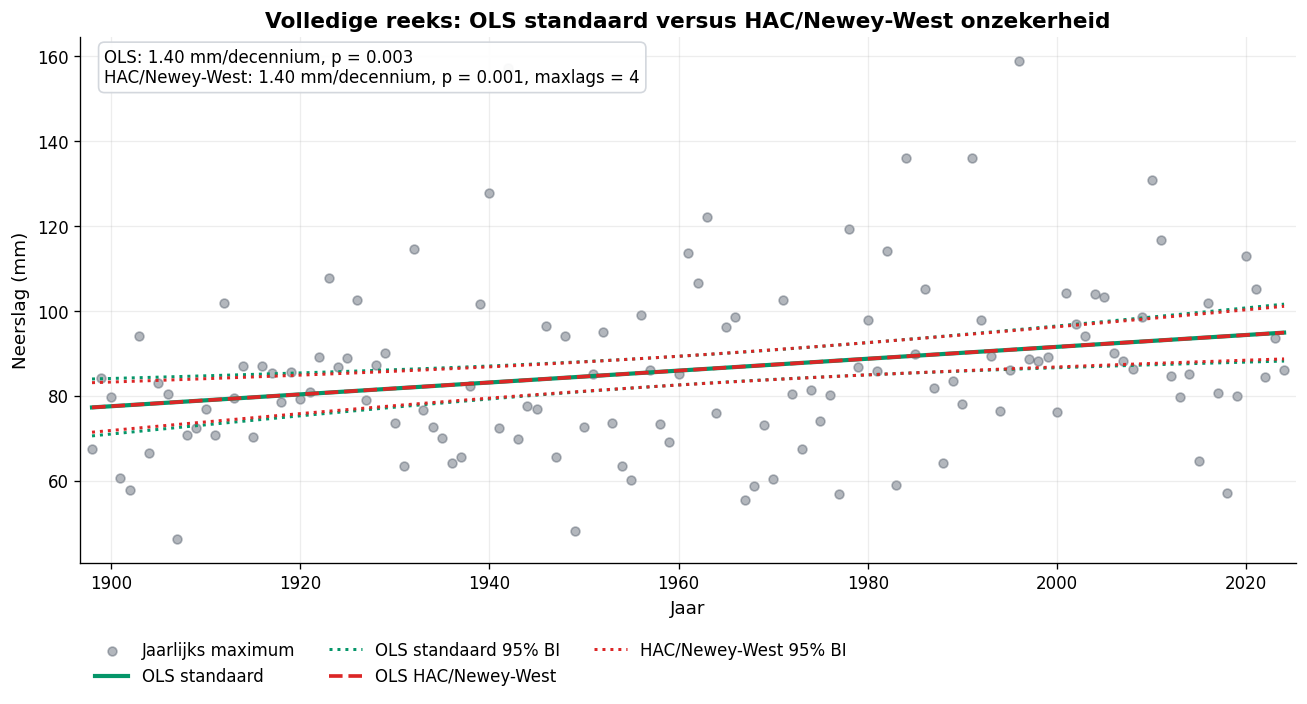

In [6]:
# Vergelijking: gewone OLS versus OLS met HAC/Newey-West robuuste onzekerheid
X_full = sm.add_constant(t_full)

ols_classic = sm.OLS(values, X_full).fit()
nw_lags_full = hac_lags(len(extreme))
ols_hac = ols_classic.get_robustcov_results(cov_type='HAC', maxlags=nw_lags_full)

ols_classic_pred = ols_classic.get_prediction(X_full).summary_frame(alpha=0.05)

hac_mean = X_full @ ols_hac.params
hac_cov = ols_hac.cov_params()
hac_mean_se = np.sqrt(np.sum((X_full @ hac_cov) * X_full, axis=1))
hac_tcrit = stats.t.ppf(0.975, df=ols_hac.df_resid)
hac_ci_low = hac_mean - hac_tcrit * hac_mean_se
hac_ci_high = hac_mean + hac_tcrit * hac_mean_se

ols_hac_table = pd.DataFrame({
    'Model': ['OLS standaard', 'OLS HAC/Newey-West'],
    'Intercept': [ols_classic.params[0], ols_hac.params[0]],
    'Trend (mm/decennium)': [ols_classic.params[1] * 10, ols_hac.params[1] * 10],
    'Std. fout trend': [ols_classic.bse[1] * 10, ols_hac.bse[1] * 10],
    't-waarde trend': [ols_classic.tvalues[1], ols_hac.tvalues[1]],
    'p-waarde trend': [format_p(ols_classic.pvalues[1]), format_p(ols_hac.pvalues[1])],
    'CI95 trend laag': [ols_classic.conf_int(alpha=0.05)[1, 0] * 10, ols_hac.conf_int(alpha=0.05)[1, 0] * 10],
    'CI95 trend hoog': [ols_classic.conf_int(alpha=0.05)[1, 1] * 10, ols_hac.conf_int(alpha=0.05)[1, 1] * 10],
    'HAC maxlags': [np.nan, nw_lags_full],
})

ols_hac_tests = pd.DataFrame({
    'Kenmerk': [
        'Aantal jaren',
        'Periode',
        'R-kwadraat',
        'Durbin-Watson residualen',
        'Ljung-Box lag 10 p-waarde',
        'HAC/Newey-West maxlags',
    ],
    'Waarde': [
        int(ols_classic.nobs),
        f'{int(years.min())}-{int(years.max())}',
        ols_classic.rsquared,
        durbin_watson(ols_classic.resid),
        format_p(acorr_ljungbox(ols_classic.resid, lags=[10], return_df=True).loc[10, 'lb_pvalue']),
        nw_lags_full,
    ],
})

display(ols_hac_table.round({
    'Intercept': 3,
    'Trend (mm/decennium)': 3,
    'Std. fout trend': 3,
    't-waarde trend': 3,
    'CI95 trend laag': 3,
    'CI95 trend hoog': 3,
    'HAC maxlags': 0,
}))
display(ols_hac_tests)

fig, ax = plt.subplots()
ax.scatter(years, values, color=COLORS['observed'], alpha=0.42, s=28, label='Jaarlijks maximum')

ax.plot(years, ols_classic_pred['mean'], color=COLORS['accent'], linewidth=2.5, label='OLS standaard')
ax.plot(years, ols_classic_pred['mean_ci_lower'], color=COLORS['accent'], linestyle=':', linewidth=1.8, label='OLS standaard 95% BI')
ax.plot(years, ols_classic_pred['mean_ci_upper'], color=COLORS['accent'], linestyle=':', linewidth=1.8)

ax.plot(years, hac_mean, color=COLORS['recent'], linewidth=2.2, linestyle='--', label='OLS HAC/Newey-West')
ax.plot(years, hac_ci_low, color=COLORS['recent'], linestyle=':', linewidth=1.8, label='HAC/Newey-West 95% BI')
ax.plot(years, hac_ci_high, color=COLORS['recent'], linestyle=':', linewidth=1.8)

ax.text(
    0.02,
    0.98,
    f'OLS: {ols_classic.params[1] * 10:.2f} mm/decennium, p = {ols_classic.pvalues[1]:.3f}\n'
    f'HAC/Newey-West: {ols_hac.params[1] * 10:.2f} mm/decennium, p = {ols_hac.pvalues[1]:.3f}, maxlags = {nw_lags_full}',
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox={'facecolor': 'white', 'edgecolor': '#D1D5DB', 'alpha': 0.94, 'boxstyle': 'round,pad=0.35'},
)
ax.set_title('Volledige reeks: OLS standaard versus HAC/Newey-West onzekerheid')
ax.set_xlabel('Jaar')
ax.set_ylabel('Neerslag (mm)')
ax.legend(loc='upper left', bbox_to_anchor=(0, -0.12), ncol=3)
ax.margins(x=0.01)
plt.tight_layout()
plt.show()


## 5. Diagnostiek van de regressie vanaf 1981

De recente trend is alleen bruikbaar als samenvatting wanneer de residualen niet sterk gestructureerd blijven. Daarom controleren we autocorrelatie expliciet met lag-1 autocorrelatie, Durbin-Watson en Ljung-Box tests.


,Diagnose,Waarde
0,Aantal jaren sinds 1981,44.0000
1,HAC maxlags,3.0000
2,Lag-1 autocorrelatie residualen,-0.0722
3,Durbin-Watson residualen,2.1360


,Ljung-Box statistic,p-waarde
1,0.2431,0.6220
5,7.8714,0.1635
10,12.9023,0.2292


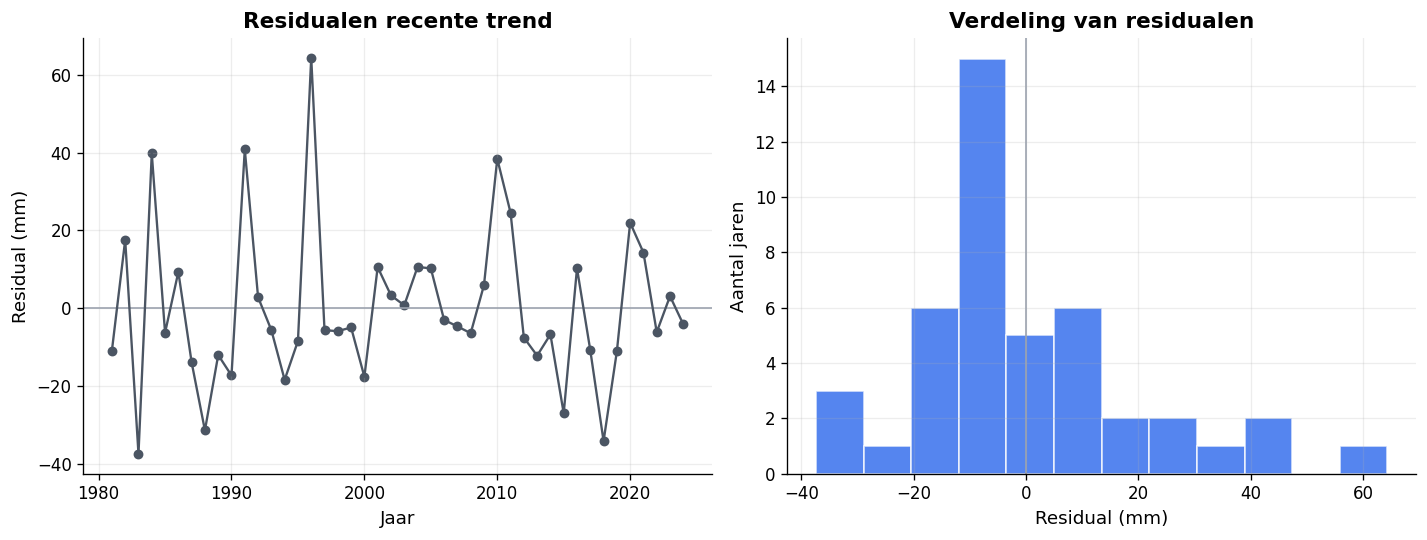

In [8]:
residuals_recent = pd.Series(ols_recent.resid, index=recent['Jaar'])
residual_diagnostics = pd.DataFrame({
    'Diagnose': [
        'Aantal jaren sinds 1981',
        'HAC maxlags',
        'Lag-1 autocorrelatie residualen',
        'Durbin-Watson residualen',
    ],
    'Waarde': [
        len(recent),
        recent_hac_lags,
        residuals_recent.autocorr(lag=1),
        durbin_watson(residuals_recent),
    ],
})

ljung_box = (
    acorr_ljungbox(residuals_recent, lags=[1, 5, 10], return_df=True)
    .rename(columns={'lb_stat': 'Ljung-Box statistic', 'lb_pvalue': 'p-waarde'})
)

display(residual_diagnostics.round(4))
display(ljung_box.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].axhline(0, color=COLORS['neutral'], linewidth=1)
axes[0].plot(residuals_recent.index, residuals_recent, color=COLORS['observed'], linewidth=1.4)
axes[0].scatter(residuals_recent.index, residuals_recent, color=COLORS['observed'], s=24)
axes[0].set_title('Residualen recente trend')
axes[0].set_xlabel('Jaar')
axes[0].set_ylabel('Residual (mm)')

axes[1].hist(residuals_recent, bins=12, color=COLORS['loess'], alpha=0.78, edgecolor='white')
axes[1].axvline(0, color=COLORS['neutral'], linewidth=1)
axes[1].set_title('Verdeling van residualen')
axes[1].set_xlabel('Residual (mm)')
axes[1].set_ylabel('Aantal jaren')
plt.tight_layout()
plt.show()


**Interpretatie diagnostiek**

De diagnostiek geeft geen aanwijzing voor problematische autocorrelatie in de residualen van de recente regressie. De lag-1 autocorrelatie is klein en licht negatief (`-0,072`), terwijl een Durbin-Watsonwaarde van `2,14` dicht bij de referentiewaarde `2` ligt. Dat past bij residualen die niet systematisch jaar-op-jaar blijven doorwerken.

Ook de Ljung-Box tests blijven ruim boven de gebruikelijke 5%-grens (`p = 0,62` bij lag 1, `p = 0,16` bij lag 5 en `p = 0,23` bij lag 10). We verwerpen dus niet de nulhypothese dat de residualen geen autocorrelatie bevatten. De figuur ondersteunt dat beeld: de residualen schommelen rond nul zonder duidelijke opeenvolgende blokken of trend, al blijft de spreiding visueel niet perfect normaal.

Voor de trendinterpretatie betekent dit dat de lineaire regressie vanaf 1981 niet duidelijk wordt ondermijnd door autocorrelatie in de fouttermen. Het gebruik van HAC/Newey-West standaardfouten met `maxlags = 3` blijft wel zinvol als voorzichtige rapportagekeuze, omdat de steekproef beperkt is tot 44 jaren en jaarlijkse klimaatreeksen in principe methodisch gevoelig kunnen zijn voor temporele afhankelijkheid.

De tijdsreeks is dus in dit geval stationair.



#conclusie (voorlopig)

VMM gebruikt een statistisch 'correcte' techniek (OLS), maar niet de aanbevolen klimatologische analysemethodiek zoals toegepast door KNMI/KMI.

In de klimatologische literatuur (o.a. KNMI TR-389) wordt afgeraden om lange klimaattijdreeksen met één globale lineaire trend te beschrijven. Dergelijke reeksen vertonen doorgaans niet-lineaire evoluties en regimewissels. Daarom wordt aanbevolen om smoothing-technieken zoals LOESS te gebruiken voor de volledige periode en lineaire trends enkel te berekenen voor recente deelperiodes. Deze aanpak wordt ook toegepast in het KMI-klimaatrapport, waar een LOESS-curve voor de volledige reeks gecombineerd wordt met een lineaire trend sinds 1981.
